# EDA — Questions Test Dataset (Fixed Parsing)
## EnterpriseRAG-Bench: `data/questions/test.parquet`

Đây là notebook EDA được sửa lỗi hoàn toàn dựa trên cấu trúc thực tế của dataset.

**Cột thực tế:** `question_id`, `question_type`, `source_types`, `question`, `expected_doc_ids`, `gold_answer`, `answer_facts`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import ast

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
pd.set_option('display.max_colwidth', 120)

PARQUET_PATH = '../data/EnterpriseRAG-Bench/data/questions/test.parquet'

print('📦 Đang tải file parquet...')
df = pd.read_parquet(PARQUET_PATH)
print(f'✅ Tải thành công: {len(df):,} câu hỏi')
print(f'Các cột: {list(df.columns)}')


📦 Đang tải file parquet...
✅ Tải thành công: 500 câu hỏi
Các cột: ['question_id', 'question_type', 'source_types', 'question', 'expected_doc_ids', 'gold_answer', 'answer_facts']


## 1. Tổng quan cấu trúc dữ liệu

In [2]:
print('=== Kiểu dữ liệu ===')
df.info()
print()
print('=== 3 dòng đầu ===')
df.head(3)

=== Kiểu dữ liệu ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   question_id       500 non-null    object
 1   question_type     500 non-null    object
 2   source_types      500 non-null    object
 3   question          500 non-null    object
 4   expected_doc_ids  500 non-null    object
 5   gold_answer       500 non-null    object
 6   answer_facts      500 non-null    object
dtypes: object(7)
memory usage: 27.5+ KB

=== 3 dòng đầu ===


,question_id,question_type,source_types,question,expected_doc_ids,gold_answer,answer_facts
0,qst_0001,basic,[github],What are the default size limits for file uploads and total request size for the new multipart upload support on the...,[dsid_ae068ee4aa9640159427cd941bef0238],The default limits are 10 MiB per file (max_file_size) and 50 MiB total per request (max_total_request_size) for mul...,[The default per file upload size limit (max_file_size) for multipart uploads on OpenAI-compatible endpoints is 10 M...
1,qst_0002,basic,[github],What is the name of the new metric added so SRE can track when server-side streaming sessions get finalized due to h...,[dsid_9550250a59e74f1bbd5612480b2e7100],The new metric is `stream.timebox_finalized` (with labels for route and model).,"[The new metric added is named stream.timebox_finalized, The metric stream.timebox_finalized includes labels for rou..."
2,qst_0003,basic,[linear],What are the acceptance criteria for the project introducing an algorithm to generate interactive UI color states an...,[dsid_3fd6af404fae48e6b8ea5a57875ef78f],"The acceptance criteria are: (1) deliver a stable design JSON token spec including the base palette, interactive der...","[Deliver a stable design JSON token spec that includes the base palette, interactive derivative tokens (for example ..."


In [3]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else '✅ Không có missing values')

=== Missing Values ===
✅ Không có missing values


## 2. Phân tích `question_type` (10 loại câu hỏi)

Số loại câu hỏi: 10
question_type
basic                       175
semantic                    125
intra_document_reasoning     40
project_related              40
constrained                  30
conflicting_info             20
completeness                 20
miscellaneous                20
info_not_found               20
high_level                   10
Name: count, dtype: int64


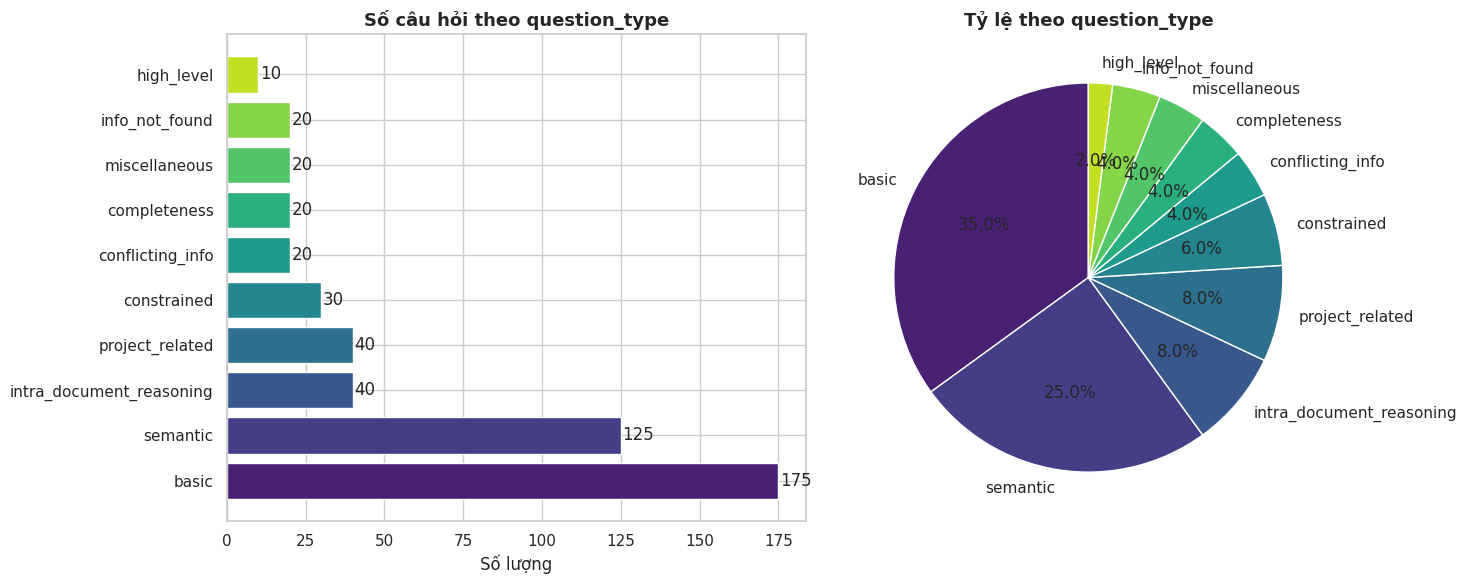

In [4]:
cat_counts = df['question_type'].value_counts()
print('Số loại câu hỏi:', df['question_type'].nunique())
print(cat_counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
colors = sns.color_palette('viridis', len(cat_counts))
axes[0].barh(cat_counts.index.tolist(), cat_counts.values, color=colors)
axes[0].set_title('Số câu hỏi theo question_type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số lượng')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 0.5, i, str(v), va='center')

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index.tolist(),
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('viridis', len(cat_counts)))
axes[1].set_title('Tỷ lệ theo question_type', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Phân tích `source_types` (nguồn tài liệu liên quan)

Cột `source_types` chứa mảng dữ liệu. Đây là metadata quan trọng nhất cho **Targeted Metadata Filtering** của T-RAG.

In [5]:
sample_val = df['source_types'].iloc[0]
print(f'Kiểu dữ liệu ô source_types: {type(sample_val)}')

def parse_array(val):
    if isinstance(val, (list, np.ndarray)):
        return list(val)
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return [val]
    return []

df['source_types_parsed'] = df['source_types'].apply(parse_array)

# Đếm unique sources (sau khi explode)
exploded = df.explode('source_types_parsed')
src_counts = exploded['source_types_parsed'].value_counts()
print('\nSố câu hỏi liên quan đến từng nguồn:')
print(src_counts)

Kiểu dữ liệu ô source_types: <class 'numpy.ndarray'>

Số câu hỏi liên quan đến từng nguồn:
source_types_parsed
confluence      114
jira            100
slack            79
github           60
google_drive     60
linear           58
gmail            55
hubspot          34
fireflies        25
Name: count, dtype: int64


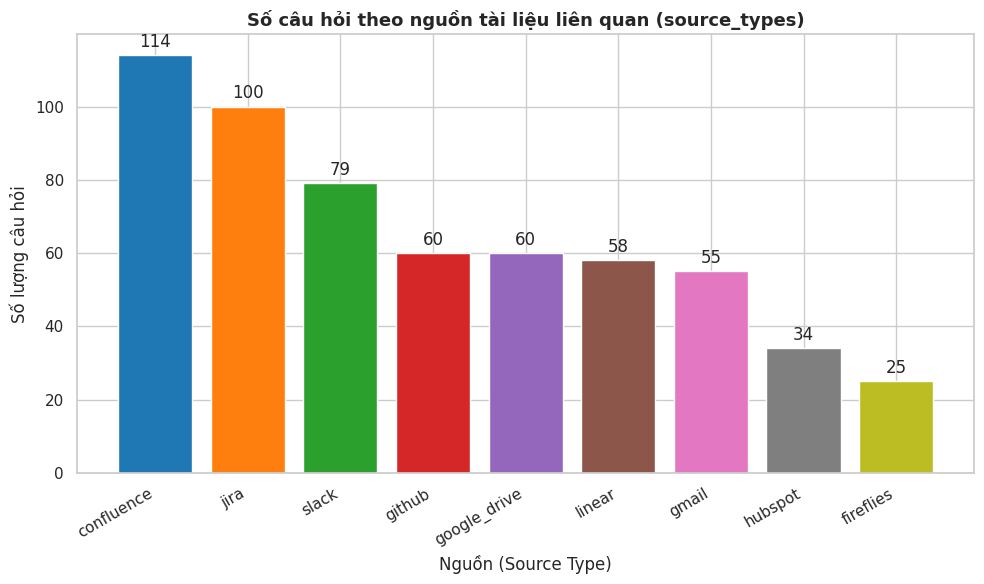

In [6]:
if len(src_counts) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(src_counts.index.tolist(), src_counts.values,
                  color=sns.color_palette('tab10', len(src_counts)))
    ax.set_title('Số câu hỏi theo nguồn tài liệu liên quan (source_types)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Nguồn (Source Type)')
    ax.set_ylabel('Số lượng câu hỏi')
    ax.bar_label(bars, padding=3)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Không có data hợp lệ sau khi parse.')

In [7]:
# Phân tích số nguồn mỗi câu hỏi (single-source vs multi-source)
df['num_sources'] = df['source_types_parsed'].apply(len)
print('Số nguồn mỗi câu hỏi:')
print(df['num_sources'].value_counts().sort_index())
print(f"\nSingle-source questions: {(df['num_sources'] == 1).sum()} ({(df['num_sources'] == 1).mean()*100:.1f}%)")
print(f"Multi-source questions:  {(df['num_sources'] > 1).sum()} ({(df['num_sources'] > 1).mean()*100:.1f}%)")

Số nguồn mỗi câu hỏi:
num_sources
0     30
1    402
2     39
3     16
4      8
5      5
Name: count, dtype: int64

Single-source questions: 402 (80.4%)
Multi-source questions:  68 (13.6%)


## 4. Phân tích độ dài câu hỏi (Query Length)

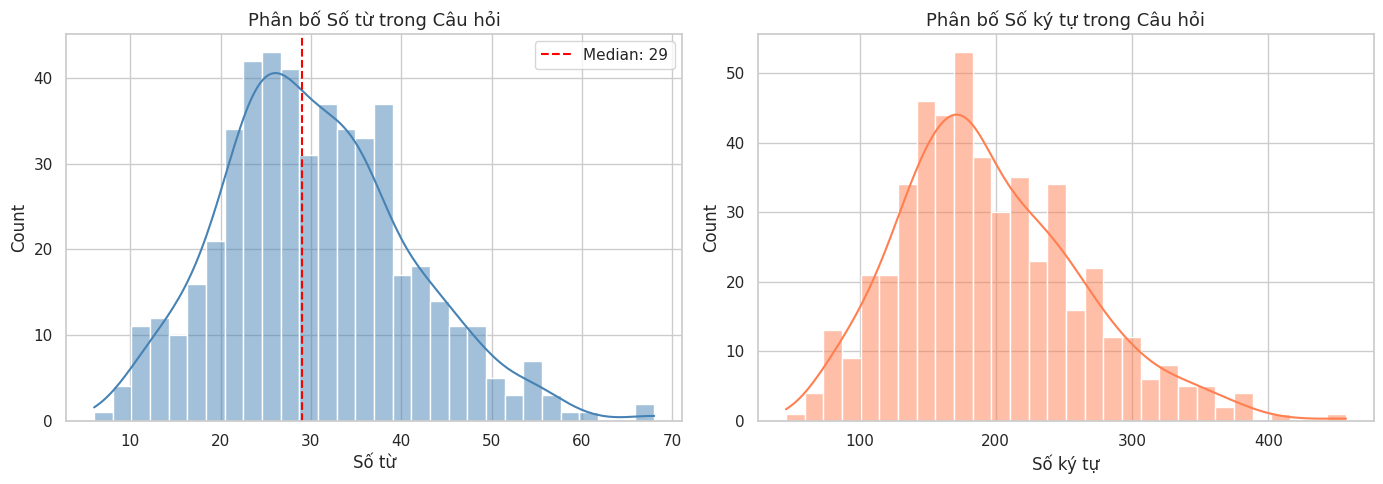

=== Thống kê số từ ===
count    500.0
mean      30.5
std       10.4
min        6.0
25%       23.0
50%       29.0
75%       37.0
max       68.0
Name: q_word_count, dtype: float64


In [8]:
df['q_word_count'] = df['question'].astype(str).apply(lambda x: len(x.split()))
df['q_char_count'] = df['question'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['q_word_count'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Phân bố Số từ trong Câu hỏi', fontsize=13)
axes[0].set_xlabel('Số từ')
median_words = df['q_word_count'].median()
axes[0].axvline(median_words, color='red', linestyle='--', label=f'Median: {median_words:.0f}')
axes[0].legend()

sns.histplot(df['q_char_count'], bins=30, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Phân bố Số ký tự trong Câu hỏi', fontsize=13)
axes[1].set_xlabel('Số ký tự')

plt.tight_layout()
plt.show()

print('=== Thống kê số từ ===')
print(df['q_word_count'].describe().round(1))

## 5. Phân tích `expected_doc_ids` (Ground Truth)

Số lượng tài liệu cần truy xuất mỗi câu hỏi → quyết định Recall@K cần đạt được.

Kiểu dữ liệu ô expected_doc_ids: <class 'numpy.ndarray'>


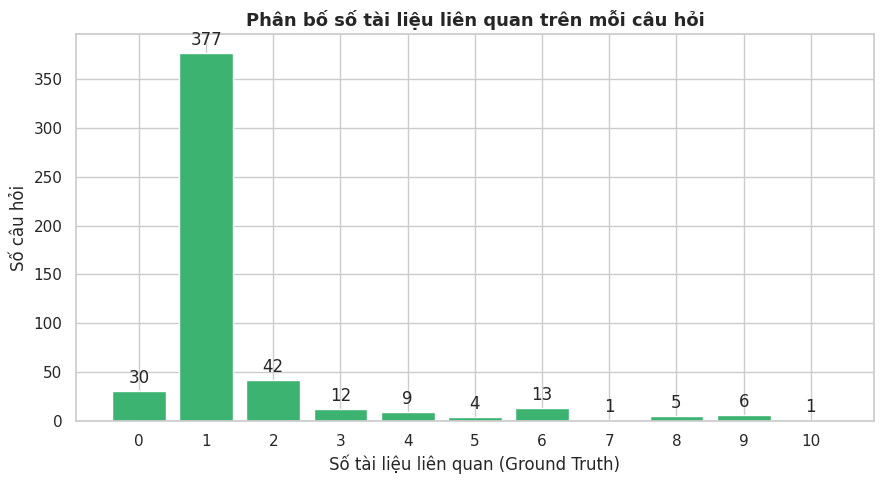


=== Thống kê số tài liệu liên quan / câu hỏi ===
count    500.0
mean       1.5
std        1.6
min        0.0
25%        1.0
50%        1.0
75%        1.0
max       10.0
Name: num_expected_docs, dtype: float64

Câu hỏi không có tài liệu (unanswerable): 30
Câu hỏi single-doc (1 tài liệu): 377
Câu hỏi multi-doc (>1 tài liệu): 93


In [9]:
sample_gt = df['expected_doc_ids'].iloc[0]
print(f'Kiểu dữ liệu ô expected_doc_ids: {type(sample_gt)}')

df['expected_doc_ids_parsed'] = df['expected_doc_ids'].apply(parse_array)
df['num_expected_docs'] = df['expected_doc_ids_parsed'].apply(len)

fig, ax = plt.subplots(figsize=(9, 5))
vc = df['num_expected_docs'].value_counts().sort_index()
ax.bar(vc.index.astype(str).tolist(), vc.values, color='mediumseagreen')
ax.bar_label(ax.containers[0], padding=3)
ax.set_title('Phân bố số tài liệu liên quan trên mỗi câu hỏi', fontsize=13, fontweight='bold')
ax.set_xlabel('Số tài liệu liên quan (Ground Truth)')
ax.set_ylabel('Số câu hỏi')
plt.tight_layout()
plt.show()

print('\n=== Thống kê số tài liệu liên quan / câu hỏi ===')
print(df['num_expected_docs'].describe().round(1))
print(f"\nCâu hỏi không có tài liệu (unanswerable): {(df['num_expected_docs'] == 0).sum()}")
print(f"Câu hỏi single-doc (1 tài liệu): {(df['num_expected_docs'] == 1).sum()}")
print(f"Câu hỏi multi-doc (>1 tài liệu): {(df['num_expected_docs'] > 1).sum()}")

## 6. Đọc mẫu câu hỏi theo từng `question_type`

In [10]:
for q_type in df['question_type'].unique():
    subset = df[df['question_type'] == q_type]
    sample = subset['question'].sample(min(2, len(subset)), random_state=42).tolist()
    print(f'\n📂 question_type: [{q_type}] ({len(subset)} câu hỏi)')
    for i, q in enumerate(sample, 1):
        wrapped = textwrap.fill(str(q), width=100, initial_indent='  ', subsequent_indent='  ')
        print(f'  Q{i}: {wrapped}')


📂 question_type: [basic] (175 câu hỏi)
  Q1:   What is the corrective journal number created to move a supplier credit amount from the DEV cost
  center to the OPS cost center after it was posted incorrectly during the March close?
  Q2:   What change was introduced to reduce tail latency in a paged key value cache by defragmenting free
  space during frees and keeping frequently used key prefixes from being evicted?

📂 question_type: [semantic] (125 câu hỏi)
  Q1:   After moving a HIPAA customers production private VPC environment to a new internal token exchange
  service, why would an automation-run service identity start getting 403s when trying to act on
  behalf of a human admin for user management, even though the same action works with the humans own
  token?
  Q2:   In the private network hosted cluster console, what are the planned quick actions on the compact
  outage summary tile that on call engineers can use to stop a risky release or switch to a safer
  model option?

📂

## 7. Tổng kết cho thiết kế T-RAG

In [11]:
print('='*65)
print('         TỔNG KẾT EDA — QUESTIONS TEST DATASET')
print('='*65)
print(f'  • Tổng số câu hỏi         : {len(df):,}')
print(f'  • Số loại câu hỏi (types) : {df["question_type"].nunique()}')
print(f'  • Độ dài trung bình query  : {df["q_word_count"].mean():.1f} từ')
print(f'  • Multi-source questions   : {(df["num_sources"] > 1).mean()*100:.1f}%')
print(f'  • Multi-doc questions      : {(df["num_expected_docs"] > 1).mean()*100:.1f}%')
print(f'  • Unanswerable questions   : {(df["num_expected_docs"] == 0).mean()*100:.1f}%')
print()
print('  ➡  Implications cho T-RAG:')
print('     - Source_type field trong question dataset → có thể dùng làm')
print('       ground truth để train/eval Source-Aware Query Parser')
print('     - Multi-source questions → Hybrid Retrieval bắt buộc')
print('     - Unanswerable questions → cần xét Precision tránh hallucination')
print('     - 10 question types → ablation study có thể phân tích per-type')
print('='*65)

         TỔNG KẾT EDA — QUESTIONS TEST DATASET
  • Tổng số câu hỏi         : 500
  • Số loại câu hỏi (types) : 10
  • Độ dài trung bình query  : 30.5 từ
  • Multi-source questions   : 13.6%
  • Multi-doc questions      : 18.6%
  • Unanswerable questions   : 6.0%

  ➡  Implications cho T-RAG:
     - Source_type field trong question dataset → có thể dùng làm
       ground truth để train/eval Source-Aware Query Parser
     - Multi-source questions → Hybrid Retrieval bắt buộc
     - Unanswerable questions → cần xét Precision tránh hallucination
     - 10 question types → ablation study có thể phân tích per-type
